# Research Journal: MCMC Analysis of Galaxy UGC 02953

**Date:** March 2, 2026  
**Project:** SIDM Rotation Curves   
**Researcher:** Bayan Taqi

### 1. Research Objective
The objective of this session was to perform a Bayesian parameter estimation using Markov Chain Monte Carlo (MCMC) to constrain the dark matter halo profile of the galaxy **UGC 02953**. Specifically, we aim to find the best-fit values for the core radius ($r_m$), the virial mass ($\log_{10} M_{200}$), and the concentration ($c$).

## 2. Methodology: Bayesian Inference with `emcee`

To explore the high-dimensional parameter space, I utilized the `emcee` Python package, which implements an Affine Invariant MCMC Ensemble sampler. 

### 2.1 Configuration
- **Walkers:** 32 (Number of independent agents exploring the posterior).
- **Steps:** 10,000 (Ensuring sufficient chain length for convergence).
- **Burn-in:** The first 100 steps were discarded to remove dependencies on initial starting positions.
- **Backend:** Data was streamed to an HDF5 file (`UGC02953_sph_mcmc...h5`) to ensure reproducibility and memory efficiency.

In [7]:
%pip install emcee h5py corner matplotlib numpy

  Obtaining dependency information for corner from https://files.pythonhosted.org/packages/4e/4a/5bd0a8b981c5a93153d9eb7c63143b407cc7f8dfc9f91eedc9b6f5289eca/corner-2.2.3-py3-none-any.whl.metadata
  Using cached corner-2.2.3-py3-none-any.whl.metadata (2.2 kB)
Using cached corner-2.2.3-py3-none-any.whl (15 kB)

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install corner


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install emcee h5py

Chain shape: 10000 steps, 32 walkers, 3 parameters


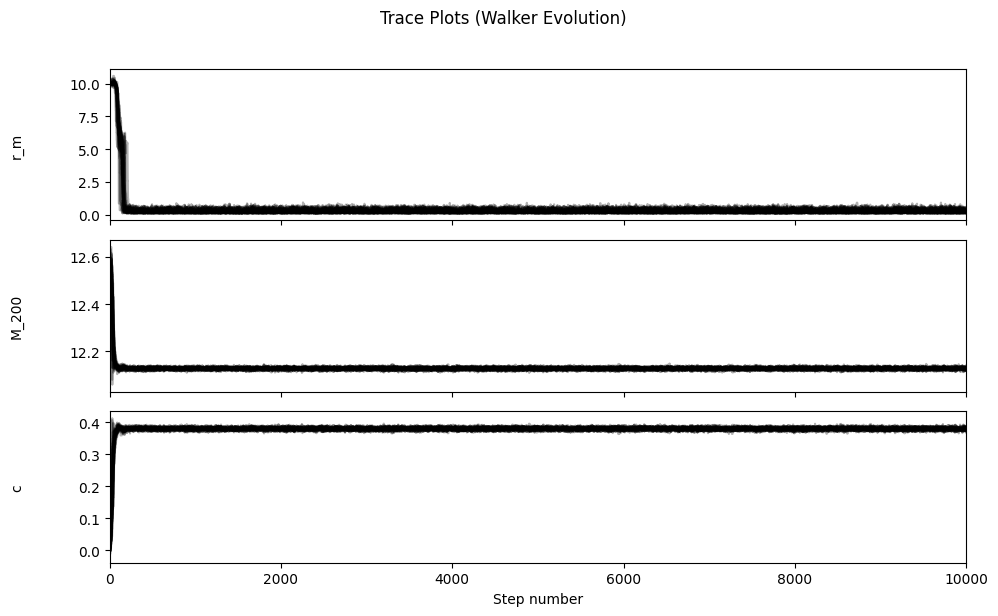

Flattened chain shape after discarding 100 steps: (316800, 3)


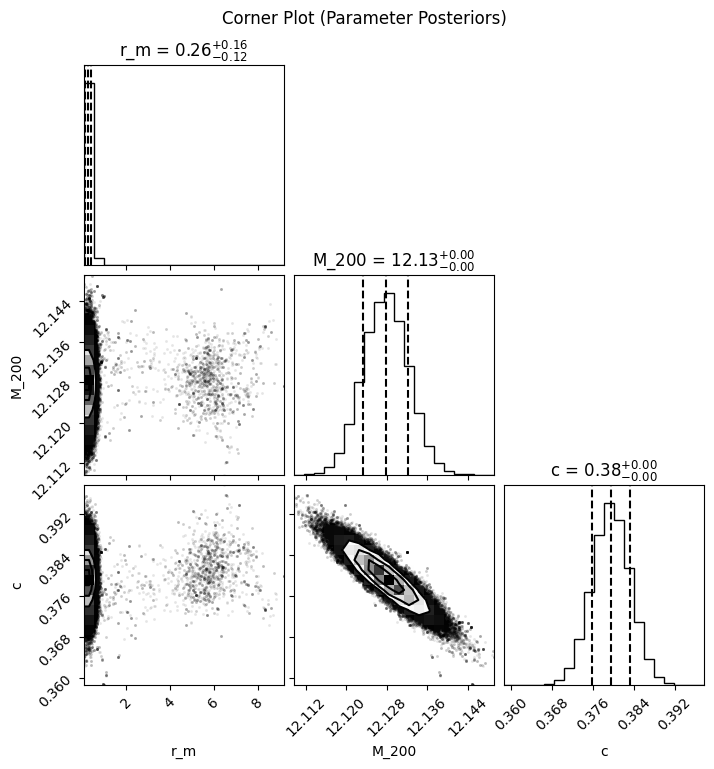


--- Best Fit Parameters (Median ± 1 sigma) ---
r_m = 0.2604 (+0.1629 / -0.1199)
M_200 = 12.1278 (+0.0044 / -0.0044)
c = 0.3795 (+0.0037 / -0.0037)


In [10]:
import emcee
import corner
import matplotlib.pyplot as plt
import numpy as np


filename = "UGC02953_sph_mcmc_nw_32_ni_10000.h5"


reader = emcee.backends.HDFBackend(filename)


# (n_steps, n_walkers, n_parameters)
chain = reader.get_chain()
n_steps, n_walkers, n_dim = chain.shape
print(f"Chain shape: {n_steps} steps, {n_walkers} walkers, {n_dim} parameters")

# Set up labels for your parameters (Update these to match your actual physics model!)
labels = ["r_m", "M_200", "c"]


#trace plots
fig, axes = plt.subplots(n_dim, figsize=(10, 2 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(chain[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step number")
plt.suptitle("Trace Plots (Walker Evolution)", y=1.02)
plt.tight_layout()
plt.show()

# Corner plots

discard_steps = 100  
flat_samples = reader.get_chain(discard=discard_steps, flat=True)
print(f"Flattened chain shape after discarding {discard_steps} steps: {flat_samples.shape}")

# Corner plots show the 1D and 2D marginalized posteriors (covariances)
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)
plt.suptitle("Corner Plot (Parameter Posteriors)", y=1.02)
plt.show()

# Extract best fit model plots
print("\n--- Best Fit Parameters (Median ± 1 sigma) ---")
best_fit_params = []

for i in range(n_dim):
    mcmc_percentiles = np.percentile(flat_samples[:, i], [16, 50, 84])
    median = mcmc_percentiles[1]
    lower_err = median - mcmc_percentiles[0]
    upper_err = mcmc_percentiles[2] - median
    
    best_fit_params.append(median)
    print(f"{labels[i]} = {median:.4f} (+{upper_err:.4f} / -{lower_err:.4f})")
